# Задача 7. Нейронные сети

* **Дедлайн**: 28.03.2025, 23:59
* **Основной полный балл**: 5
* **Максимум баллов**: 10

## Задача

- [x] Выбранный dataset: http://ufldl.stanford.edu/housenumbers/.
- [x] Реализовать классы, необходимые для построения сети со следующими слоями
	- FullyConnectedLayer
	- ReluLayer
	- FullyConnectedLayer
- [x] Использовать CrossEntropyLoss и L2-регуляризацию.
- [x] Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
- [x] * (**+2 балла**) Добавить Batch normalization.
- [x] * (**+2 балла**) В качестве оптимизатор использовать один из: Momentum, RMSprop.
- [x] * (**+1 балл**) Также реализовать оптимизатор Adam.

In [121]:
import torch
from torch import nn
import lightning as L
from torchvision.datasets import MNIST
from torch.nn import functional as F

import warnings

warnings.filterwarnings('ignore')

# Данные
В качестве данных возьмём MNIST. Необходимо определять, какая цифра от 0 до 10 находится на картинке. 

In [122]:
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

train_set = MNIST(root=".", download=True, train=True, transform=ToTensor())

torch_generator = torch.Generator().manual_seed(42)
train_set, val_set = torch.utils.data.random_split(
    train_set,
    [int(len(train_set) * 0.8), len(train_set) - int(len(train_set) * 0.8)],
    torch_generator,
)
test_set = MNIST(root=".", download=True, train=False, transform=ToTensor())

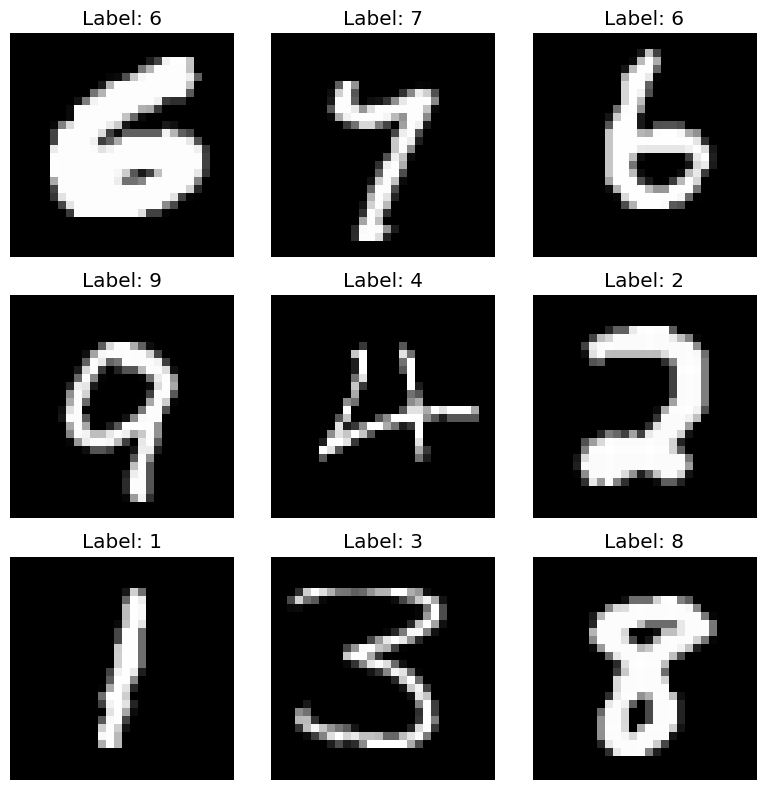

In [123]:
dataiter = iter(train_set)
image_tensor, label = next(dataiter)

image_np = image_tensor.squeeze().numpy()

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    image, label = train_set[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Слои для сети

Реализуем свои слои

In [124]:
class FullyConnectedLayerFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias):
        output = x @ weight + bias
        ctx.save_for_backward(x, weight)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        x, weight = ctx.saved_tensors
        x_grad = grad_output @ weight.T
        weight_grad = grad_output.T @ x
        bias_grad = grad_output.sum(0)

        return x_grad, weight_grad.T, bias_grad


class FullyConnectedLayer(nn.Module):
    def __init__(self, in_features, out_features, dtype=torch.float):
        super().__init__()
        self.weight = nn.Parameter(torch.empty((in_features, out_features), dtype=dtype))
        self.bias = nn.Parameter(torch.empty(out_features, dtype=dtype))
        self.init_weights()

    def forward(self, x):
        return FullyConnectedLayerFunc.apply(x, self.weight, self.bias)

    def init_weights(self):
        nn.init.kaiming_normal_(
            self.weight, mode="fan_out", nonlinearity="relu"
        )
        nn.init.uniform_(self.bias, -0.5, 0.5)


class ReluLayer(nn.Module):
    def forward(self, x):
        return F.relu(x)

#### Проверим корректность вычисления градиентов с помощью torch.autograd.gradcheck

In [125]:
torch.autograd.gradcheck(
    FullyConnectedLayerFunc.apply,
    (
        torch.rand((5, 20), requires_grad=True, dtype=torch.double),
        torch.rand((20, 10), requires_grad=True, dtype=torch.double),
        torch.rand(10, requires_grad=True, dtype=torch.double),
    ),
    eps=1e-6,
    atol=1e-4,
)

test_layer = FullyConnectedLayer(100, 200, dtype=torch.double)

torch.autograd.gradcheck(
    test_layer,
    (
        torch.rand((5, 100), requires_grad=True, dtype=torch.double)
    ),
    eps=1e-6,
    atol=1e-4,
)

True

# Adam

In [126]:
from torch.optim.optimizer import Optimizer


class Adam(Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)
        self.state = dict()
        for group in self.param_groups:
            for param in group["params"]:
                self.state[param] = {
                    "m": torch.zeros_like(param),
                    "v": torch.zeros_like(param),
                    "g": torch.zeros_like(param),
                    "t": 0,
                }

    def step(self, closure=None):
        loss = None
        if closure:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            beta_1, beta_2 = group["betas"]
            for param in group["params"]:
                if param.grad is None:
                    continue
                
                grad = param.grad.data
                if group["weight_decay"] != 0:
                    grad += group["weight_decay"] * param.data
                state = self.state[param]
                state["t"] += 1
                state["m"] = beta_1 * state["m"] + (1 - beta_1) * grad
                state["v"] = beta_2 * state["v"] + (1 - beta_2) * grad**2
                m_hat = state["m"] / (1 - beta_1 ** state["t"])
                v_hat = state["v"] / (1 - beta_2 ** state["t"])

                param.data -= group["lr"] * m_hat / (torch.sqrt(v_hat) + group["eps"])
        
        return loss

# Сеть + класс для работы с pytorch lightning

In [127]:
class MyNeuralNetwork(nn.Module):
    def __init__(self, hidden_size=100, use_batch_norm=False):
        super().__init__()

        if not use_batch_norm:
            self.sequential = nn.Sequential(
                FullyConnectedLayer(28 * 28, hidden_size),
                ReluLayer(),
                FullyConnectedLayer(hidden_size, 10),
            )
        else:
            self.sequential = nn.Sequential(
                FullyConnectedLayer(28 * 28, hidden_size),
                ReluLayer(),
                nn.BatchNorm1d(hidden_size),
                FullyConnectedLayer(hidden_size, 10),
            )

    def forward(self, x):
        return self.sequential(x)
    

In [128]:
class LitModel(L.LightningModule):
    def __init__(
        self, hidden_size, use_batch_norm, optimizer, lr, weight_decay
    ):
        super().__init__()
        self.model = MyNeuralNetwork(
            hidden_size=hidden_size, use_batch_norm=use_batch_norm
        )
        self.optimizer = optimizer(
            self.model.parameters(), lr=lr, weight_decay=weight_decay
        )

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        logits = self.model(x)
        loss = nn.functional.cross_entropy(logits, y)
        self.log("train_loss", loss.item(), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        logits = self.model(x)
        loss = nn.functional.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = torch.sum(preds == y).item() / len(y)
        self.log_dict({"val_loss": loss.item(), "val_acc": acc})

    def test_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        logits = self.model(x)
        preds = torch.argmax(logits, dim=1)
        acc = torch.sum(preds == y).item() / len(y)
        self.log_dict({"test_acc": acc})

    def configure_optimizers(self):
        return self.optimizer

# Обучение
Будем перебирать гиперпараметры: оптимизатор, lr, hidden_size и использование batch_norm

In [ ]:
from lightning.pytorch.loggers import CSVLogger

optimizers = [
    ("SGD", torch.optim.SGD),
    ("Adam", Adam),
    ("RMSprop", torch.optim.RMSprop),
]

lrs = [1e-2, 1e-3]

hidden_sizes = [100, 1000]

for optimizer in optimizers:
    for lr in lrs:
        for hidden_size in hidden_sizes:
            for use_batch_norm in [False, True]:
                train_loader = torch.utils.data.DataLoader(
                    train_set, batch_size=4096, shuffle=True, num_workers=4
                )
                val_loader = torch.utils.data.DataLoader(
                    val_set, batch_size=4096, num_workers=4
                )
                test_loader = torch.utils.data.DataLoader(
                    test_set, batch_size=4096, num_workers=4
                )
                model = LitModel(
                    hidden_size=hidden_size,
                    use_batch_norm=use_batch_norm,
                    optimizer=optimizer[1],
                    lr=lr,
                    weight_decay=0.005,
                )

                logger = CSVLogger(
                    "logs",
                    name="simple_model",
                    #    version="test"
                )
                max_epochs = 2
                logger.log_hyperparams(
                    {
                        "max_epochs": max_epochs,
                        "lr": lr,
                        "optimizer": optimizer[0],
                        "hidden_size": hidden_size,
                        "use_batch_norm": use_batch_norm,
                    }
                )
                trainer = L.Trainer(
                    max_epochs=max_epochs,
                    logger=logger,
                    accelerator="gpu",
                    log_every_n_steps=5,
                    # limit_train_batches=10,
                    # limit_val_batches=3,
                    enable_model_summary=False,
                    enable_progress_bar=False,
                )
                trainer.validate(model, dataloaders=val_loader, verbose=False)
                trainer.fit(
                    model=model,
                    train_dataloaders=train_loader,
                    val_dataloaders=val_loader,
                )
                # trainer.test(model, dataloaders=test_loader, verbose=False)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=2` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=2` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using

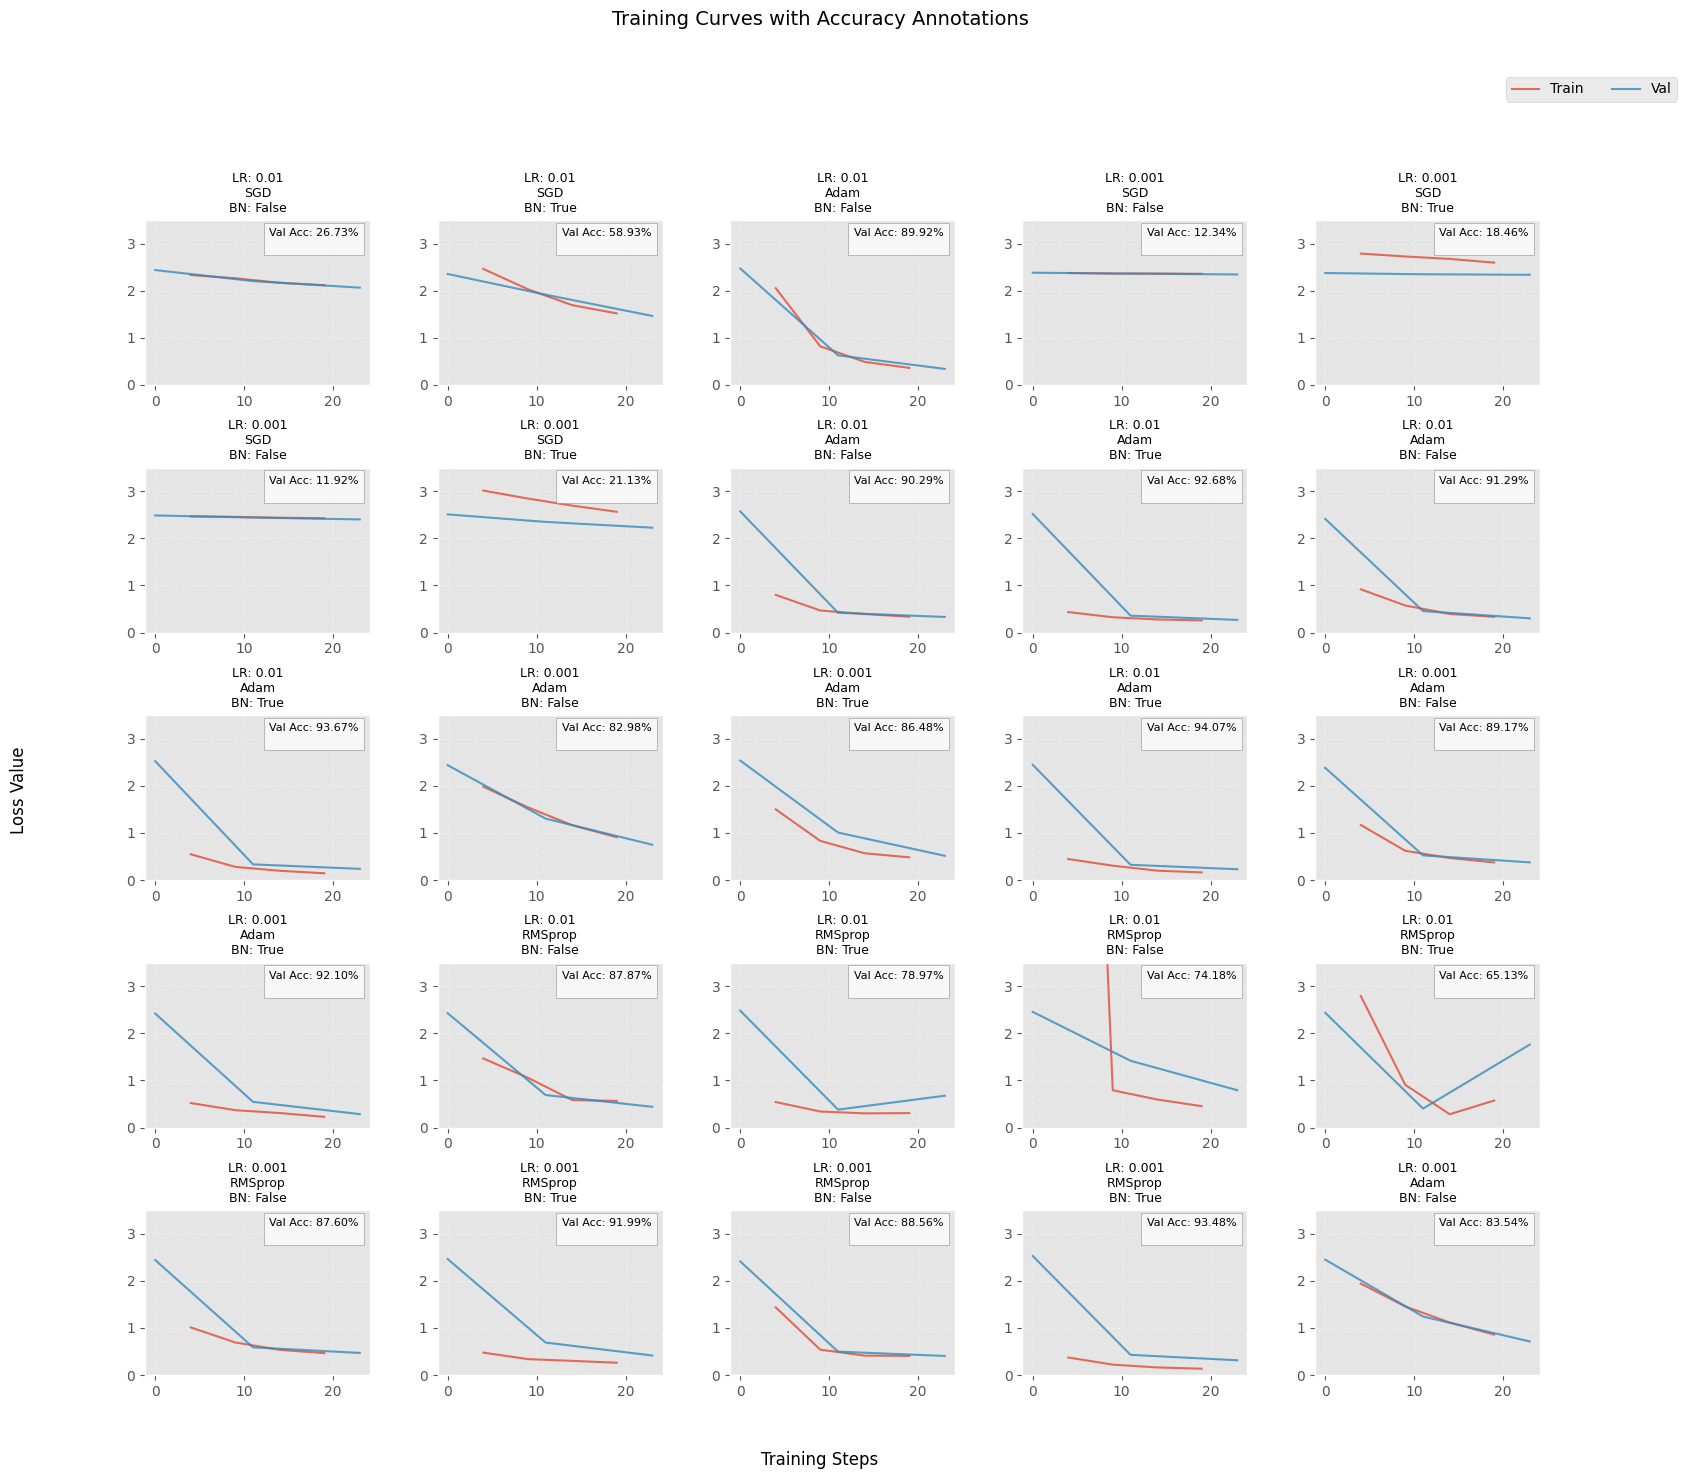

In [130]:
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import numpy as np

versions = glob("logs/simple_model/*", recursive=True)
results = []

for version in versions:
    try:
        df = pd.read_csv(f"{version}/metrics.csv")
        with open(f"{version}/hparams.yaml") as f:
            hparams = yaml.safe_load(f)
            
        final_test_acc = df['test_acc'].dropna().iloc[-1] if 'test_acc' in df.columns else np.nan
        final_val_acc = df['val_acc'].dropna().iloc[-1] if 'val_acc' in df.columns else np.nan
        
        results.append({
            'version': version,
            'df': df,
            'hparams': hparams,
            'final_test_acc': final_test_acc,
            'final_val_acc': final_val_acc
        })
    except Exception as e:
        print(f"Skipping {version}: {e}")

fig, axs = plt.subplots(5, 5, figsize=(18, 15))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Training Curves with Accuracy Annotations', y=1.02, fontsize=14)

coords = [(x, y) for x in range(5) for y in range(5)]

for coord, result in zip(coords[:len(results)], results):
    df = result['df']
    hparams = result['hparams']
    ax = axs[coord[0]][coord[1]]

    train_df = df.dropna(subset=["train_loss"])
    ax.plot(train_df["step"], train_df["train_loss"], 
           label="Train", linewidth=1.5, alpha=0.8)
    
    val_df = df.dropna(subset=["val_loss"])
    ax.plot(val_df["step"], val_df["val_loss"], 
           label="Val", linewidth=1.5, alpha=0.8)

    ax.set_ylim([0, 3.5])
    ax.grid(True, linestyle='--', alpha=0.3)
    
    acc_text = ""
    if not np.isnan(result['final_val_acc']):
        acc_text += f"Val Acc: {result['final_val_acc']:.2%}\n"
    if not np.isnan(result['final_test_acc']):
        acc_text += f"Test Acc: {result['final_test_acc']:.2%}"
    
    ax.text(0.95, 0.95, acc_text, 
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'),
            fontsize=8)
    
    title = f"LR: {hparams['lr']}\n{hparams['optimizer']}\nBN: {hparams['use_batch_norm']}"
    ax.set_title(title, fontsize=9, pad=6)

fig.text(0.5, 0.05, 'Training Steps', ha='center', fontsize=12)
fig.text(0.05, 0.5, 'Loss Value', va='center', rotation='vertical', fontsize=12)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', 
           bbox_to_anchor=(0.98, 0.98), ncol=2, fontsize=10)

plt.show()

Оставим только лучшие по val accuracy комбинации

In [ ]:
from glob import glob
import pandas as pd
import yaml

versions = glob("logs/simple_model/*", recursive = True)

map_name_val = []

for version in versions:
    df = pd.read_csv(version + '/metrics.csv').dropna(subset=['val_acc'])
    
    with open(version + '/hparams.yaml') as f:
        hparams = yaml.safe_load(f)
    
    name = f"lr{hparams['lr']}_{hparams['optimizer']}_hsize{hparams['hidden_size']}_bn{hparams['use_batch_norm']}"
    map_name_val.append((round(df['val_acc'].iloc[-1], 3), name))

map_name_val.sort()
map_name_val

[(np.float64(0.066), 'lr0.001_SGD_hsize1000_bnFalse'),
 (np.float64(0.078), 'lr0.001_SGD_hsize100_bnFalse'),
 (np.float64(0.098), 'lr0.001_SGD_hsize100_bnFalse'),
 (np.float64(0.119), 'lr0.001_SGD_hsize1000_bnFalse'),
 (np.float64(0.119), 'lr0.001_SGD_hsize1000_bnFalse'),
 (np.float64(0.123), 'lr0.001_SGD_hsize100_bnFalse'),
 (np.float64(0.127), 'lr0.001_SGD_hsize100_bnTrue'),
 (np.float64(0.128), 'lr0.001_SGD_hsize100_bnFalse'),
 (np.float64(0.138), 'lr0.001_SGD_hsize1000_bnFalse'),
 (np.float64(0.139), 'lr0.001_SGD_hsize100_bnFalse'),
 (np.float64(0.143), 'lr0.001_SGD_hsize1000_bnTrue'),
 (np.float64(0.144), 'lr0.001_SGD_hsize100_bnTrue'),
 (np.float64(0.151), 'lr0.001_SGD_hsize100_bnTrue'),
 (np.float64(0.153), 'lr0.001_SGD_hsize1000_bnFalse'),
 (np.float64(0.162), 'lr0.001_SGD_hsize1000_bnTrue'),
 (np.float64(0.185), 'lr0.001_SGD_hsize100_bnTrue'),
 (np.float64(0.206), 'lr0.01_SGD_hsize100_bnFalse'),
 (np.float64(0.208), 'lr0.001_SGD_hsize100_bnTrue'),
 (np.float64(0.211), 'lr0.001

Возьмём 4 лучших и обучим на большем числе эпох

In [132]:
from lightning.pytorch.loggers import CSVLogger

best_params = [
    (("Adam", Adam), 0.01, 100, True),
    (("Adam", Adam), 0.01, 1000, True),
    (("RMSprop", torch.optim.RMSprop), 0.001, 100, True),
    (("RMSprop", torch.optim.RMSprop), 0.001, 1000, True)
]

for (optimizer, lr, hidden_size, use_batch_norm) in best_params:
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=4096, shuffle=True, num_workers=4
    )
    val_loader = torch.utils.data.DataLoader(
        val_set, batch_size=4096, num_workers=4
    )
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=4096, num_workers=4
    )
    model = LitModel(
        hidden_size=hidden_size,
        use_batch_norm=use_batch_norm,
        optimizer=optimizer[1],
        lr=lr,
        weight_decay=0.005,
    )

    logger = CSVLogger(
        "logs",
        name="simple_model_selected_params",
        #    version="test"
    )
    max_epochs = 10
    logger.log_hyperparams(
        {
            "max_epochs": max_epochs,
            "lr": lr,
            "optimizer": optimizer[0],
            "hidden_size": hidden_size,
            "use_batch_norm": use_batch_norm,
        }
    )
    trainer = L.Trainer(
        max_epochs=max_epochs,
        logger=logger,
        accelerator="gpu",
        log_every_n_steps=5,
        # limit_train_batches=10,
        # limit_val_batches=3,
        enable_model_summary=False,
        enable_progress_bar=False,
    )
    trainer.validate(model, dataloaders=val_loader, verbose=False)
    trainer.fit(
        model=model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader,
    )
    trainer.test(model, dataloaders=test_loader, verbose=False)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (

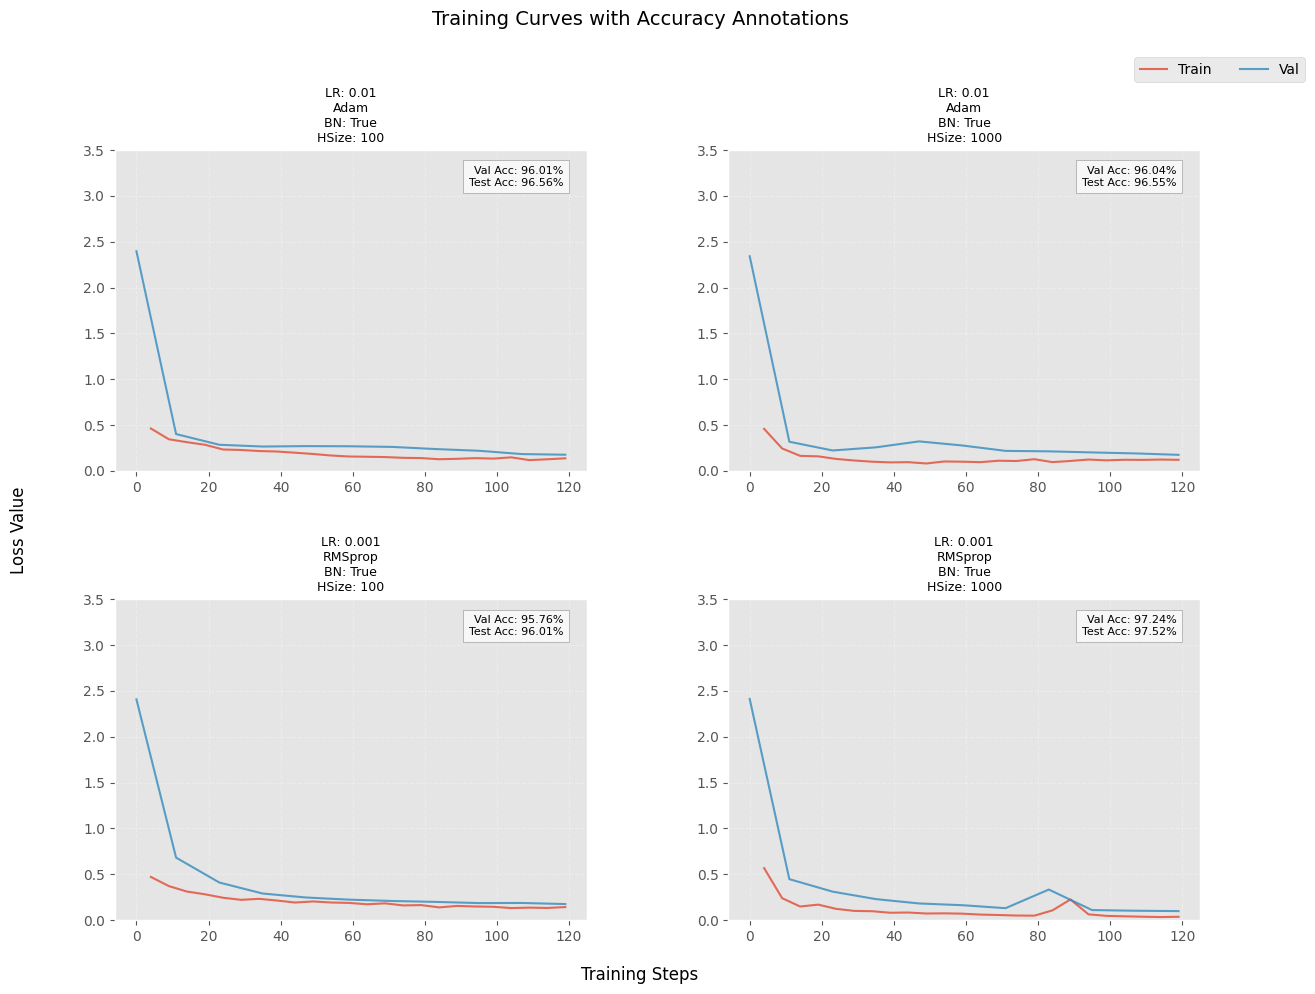

In [133]:
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import numpy as np

versions = glob("logs/simple_model_selected_params/*", recursive=True)
results = []

# First collect all data and results
for version in versions:
    try:
        df = pd.read_csv(f"{version}/metrics.csv")
        with open(f"{version}/hparams.yaml") as f:
            hparams = yaml.safe_load(f)
            
        final_val_acc = df['val_acc'].dropna().iloc[-1] if 'val_acc' in df.columns else np.nan
        final_test_acc = df['test_acc'].dropna().iloc[-1] if 'test_acc' in df.columns else np.nan
        
        results.append({
            'version': version,
            'df': df,
            'hparams': hparams,
            'final_val_acc': final_val_acc,
            'final_test_acc': final_test_acc
        })
    except Exception as e:
        print(f"Skipping {version}: {e}")

# Create the plot
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Training Curves with Accuracy Annotations', y=1.02, fontsize=14)

coords = [(x, y) for x in range(2) for y in range(2)]

for coord, result in zip(coords[:len(results)], results):
    df = result['df']
    hparams = result['hparams']
    ax = axs[coord[0]][coord[1]]

    # Plot training and validation loss
    train_df = df.dropna(subset=["train_loss"])
    ax.plot(train_df["step"], train_df["train_loss"], 
           label="Train", linewidth=1.5, alpha=0.8)
    
    val_df = df.dropna(subset=["val_loss"])
    ax.plot(val_df["step"], val_df["val_loss"], 
           label="Val", linewidth=1.5, alpha=0.8)

    ax.set_ylim([0, 3.5])
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Add accuracy annotations
    acc_text = ""
    if not np.isnan(result['final_val_acc']):
        acc_text += f"Val Acc: {result['final_val_acc']:.2%}\n"
    if not np.isnan(result['final_test_acc']):
        acc_text += f"Test Acc: {result['final_test_acc']:.2%}"
    
    ax.text(0.95, 0.95, acc_text, 
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'),
            fontsize=8)
    
    # Set title with hyperparameters
    title = f"LR: {hparams['lr']}\n{hparams['optimizer']}\nBN: {hparams['use_batch_norm']}\nHSize: {hparams['hidden_size']}"
    ax.set_title(title, fontsize=9, pad=6)

# Add common labels
fig.text(0.5, 0.05, 'Training Steps', ha='center', fontsize=12)
fig.text(0.05, 0.5, 'Loss Value', va='center', rotation='vertical', fontsize=12)

# Add legend
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', 
           bbox_to_anchor=(0.98, 0.98), ncol=2, fontsize=10)

plt.show()

In [136]:
from glob import glob
import pandas as pd
import yaml

versions = glob("logs/simple_model_selected_params/*", recursive=True)

results = []

for version in versions:
    df = pd.read_csv(version + '/metrics.csv').dropna(subset=['val_acc'])
    
    with open(version + '/hparams.yaml') as f:
        hparams = yaml.safe_load(f)
    
    results.append({
        'Learning Rate': hparams['lr'],
        'Optimizer': hparams['optimizer'],
        'Hidden Size': hparams['hidden_size'],
        'Batch Norm': hparams['use_batch_norm'],
        'Val Accuracy': round(df['val_acc'].iloc[-1], 3)
    })

# Создаем DataFrame и сортируем по точности (по убыванию)
results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False)

# Добавляем столбец с рангами
results_df.insert(0, 'Rank', range(1, len(results_df)+1))

# Выделяем лучшую строку
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

styled_df = results_df.style.apply(highlight_max, subset=['Val Accuracy'])

# Отображаем таблицу
display(styled_df)

,Rank,Learning Rate,Optimizer,Hidden Size,Batch Norm,Val Accuracy
13,1,0.001000,RMSprop,1000,True,0.974000
3,2,0.001000,RMSprop,1000,True,0.972000
7,3,0.001000,RMSprop,1000,True,0.972000
11,4,0.001000,RMSprop,1000,True,0.964000
19,5,0.010000,Adam,1000,True,0.961000
5,6,0.010000,Adam,1000,True,0.960000
0,7,0.010000,Adam,100,True,0.960000
1,8,0.010000,Adam,1000,True,0.960000
4,9,0.010000,Adam,100,True,0.959000
2,10,0.001000,RMSprop,100,True,0.958000


Как можно заметить, побеждает комбинация с   
lr=0.001  
optimizer=RMSprop  
hidden_size=1000  
batch_norm=True  

In [ ]:
from glob import glob
import pandas as pd
import yaml

version = glob("logs/simple_model_selected_params/*", recursive = True)[2]


df = pd.read_csv(version + '/metrics.csv').dropna(subset=['test_acc'])
with open(version + '/hparams.yaml') as f:
    hparams = yaml.safe_load(f)
print(f"lr{hparams['lr']}_{hparams['optimizer']}", df['test_acc'].iloc[0])



lr0.001_RMSprop 0.960099995136261


На тестовом датасете accuracy 0.960